In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from offers.logging_config import configure_logging
from offers.companies.visionite import calc_compensation, print_table, find_itp1_pension
from offers.loader import load_tax_table, load_toml
from offers.pension import itp1
from offers.tax import salary_sweep, tax_for_salary

configure_logging()

In [63]:
income = 120960
pot = 2500
car = 4495

pension = find_itp1_pension(income=income, pot=pot, car=car)

total_compensation = calc_compensation(
    income=income,
    pension=6900,
    pot=pot,
    car=car,
)
print_table(total_compensation)

───────────────────────────────────────────────── 
   Egen intäkt                        120 960 kr   
 ───────────────────────────────────────────────── 
   Skatter och avgifter                            
 ───────────────────────────────────────────────── 
   Semesteravsättning                   9 951 kr   
 ───────────────────────────────────────────────── 
   Arbetsverktyg & Trygghetspaket       1 500 kr   
 ───────────────────────────────────────────────── 
   Arbetsgivaravgifter                 24 838 kr   
 ───────────────────────────────────────────────── 
   Löneskatt på tjänstepension          1 674 kr   
 ───────────────────────────────────────────────── 
   Bruttolön                           69 102 kr   
 ───────────────────────────────────────────────── 
   Tjänstepension                       6 900 kr   
 ───────────────────────────────────────────────── 
   Sparande till Visionite-konto        2 500 kr   
 ───────────────────────────────────────────────── 
   Bilkostnad                           4 495 kr   
 ───────────────────────────────────────────────── 
   Tabellskatt                         20 871 kr   
 ───────────────────────────────────────────────── 
   Nettolön                            48 231 kr   
 ─────────────────────────────────────────────────

In [32]:
total_compensation = calc_compensation(
    income=income,
    pension=9000,
    pot=20000,
    car=car,
)
print_table(total_compensation)

───────────────────────────────────────────────── 
   Egen intäkt                        120 960 kr   
 ───────────────────────────────────────────────── 
   Skatter och avgifter                            
 ───────────────────────────────────────────────── 
   Semesteravsättning                   8 455 kr   
 ───────────────────────────────────────────────── 
   Arbetsverktyg & Trygghetspaket       1 500 kr   
 ───────────────────────────────────────────────── 
   Arbetsgivaravgifter                 21 105 kr   
 ───────────────────────────────────────────────── 
   Löneskatt på tjänstepension          2 183 kr   
 ───────────────────────────────────────────────── 
   Bruttolön                           58 716 kr   
 ───────────────────────────────────────────────── 
   Tjänstepension                       9 000 kr   
 ───────────────────────────────────────────────── 
   Sparande till Visionite-konto       20 000 kr   
 ───────────────────────────────────────────────── 
   Bilkostnad                               0 kr   
 ───────────────────────────────────────────────── 
   Tabellskatt                         15 359 kr   
 ───────────────────────────────────────────────── 
   Nettolön                            43 357 kr   
 ─────────────────────────────────────────────────

In [47]:
p0 = 2500
p1 = 0
n = 1

total_compensation = calc_compensation(
    income=income,
    pension=8000,
    pot=p0 + p1,
    car=car,
)
x1 = n * total_compensation.net_salary + n * p1 * (1 - 0.54)
x1

49252.0

In [48]:
p0 = 2500
p1 = 20000 - p0
n = 1

total_compensation = calc_compensation(
    income=income,
    pension=8000,
    pot=p0 + p1,
    car=car,
)
x2 = n * total_compensation.net_salary + n * p1 * (1 - 0.54)
x2

51810.0

In [55]:
x = []
for i in range(12):
    if x:
        next_x = x[-1] * 1.12**(1/12) + 2558
    else:
        next_x = 2558
    x.append(next_x)
x = np.array(x)
x

array([ 2558.        ,  5140.27233233,  7747.04731212, 10378.55743991,
       13035.03742242, 15716.72419342, 18423.8569349 , 21156.67709841,
       23915.42842658, 26700.35697486, 29511.71113348, 32349.74164957])

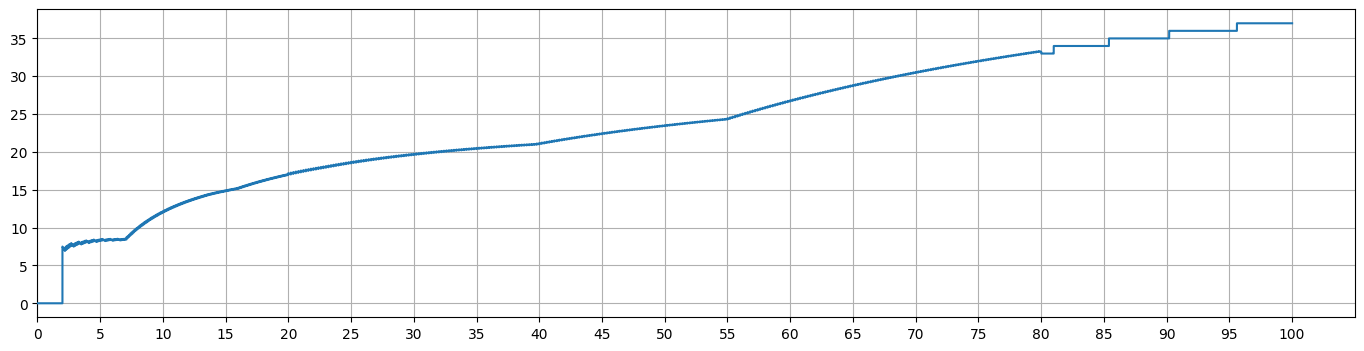

In [20]:
fig, ax = plt.subplots(figsize=(17, 4))
ax.plot(df["salary"]*1e-3, 100 * df["tax"]/ df["salary"], zorder=3)
ax.grid(zorder=1)
ax.set_xticks(np.arange(0, 101, 5))
ax.set_xlim(0, None)
# ax.tick_params(axis="x", rotation=90)
plt.show()